# Pendulum swing-up — algorithm bake-off

Closed-loop inverted-pendulum swing-up (drive θ → π). Imports every algorithm from the package and compares them under normal vs. FPL cost via the shared `analytic_mppi.eval` harness — no monkey-patching, no cell-ordering deps.

In [24]:
# Always pick up the latest code in analytic_mppi/ (incl. experimental.py)
# without restarting the kernel — edit a .py, re-run a cell, done.
%load_ext autoreload
%autoreload 2

import numpy as np
from analytic_mppi.tasks import make_task
from analytic_mppi.dynamics import MujocoBackend
from analytic_mppi.eval import (
    Config, run_study, plot_study, summarize, render_video,
    pendulum_metrics, pendulum_panels, pendulum_metrics, pendulum_panels, init_hang_down
)
# Controllers are imported straight from the package (autoreloaded):
from analytic_mppi.controllers import MPPIv2, MppiCma, CEM, DIAL, PredictiveSampling
from analytic_mppi.controllers.experimental import UniformGD, GaussianGD, RankCMA, FplValueCMA, FplGmmSampler

TASK = "pendulum"
task = make_task(TASK)
DT = MujocoBackend(task.model_path).dt
print(f"task={TASK}  nq={task.nq} nv={task.nv} nu={task.nu} dt={DT}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
task=pendulum  nq=1 nv=1 nu=1 dt=0.02


## Experiment configuration

Each `Config` is one row of the comparison: a label, the controller **class** (imported above), the cost mode, and its algo-specific kwargs. Shared sampler settings apply to every row.

In [ ]:
# sampler settings shared by every config (K > 1 so sampling actually happens)
SHARED = dict(num_samples=64, plan_horizon=1.0, num_knots=4)

CONFIGS = [
    Config("mppi  (normal)",          MPPIv2,       "normal",         dict(noise_level=0.3, temperature=0.1)),
    # Config("mppi_cma  (normal)",      MppiCma,      "normal",         dict(initial_noise_level=0.5, temperature=0.1, minimum_noise_level=0.1)),
    Config("mppi  (fpl)",             MPPIv2,       "fpl_discounted", dict(noise_level=0.3, temperature=0.1)),
    # Config("mppi_cma  (fpl)",         MppiCma,      "fpl_discounted", dict(initial_noise_level=0.5, temperature=0.1, minimum_noise_level=0.1)),
    # Config("uniform_gd  (fpl)",       UniformGD,    "fpl_discounted", dict(noise_level=0.5, n_gd_iter=5)),
    # Config("gaussian_gd  (fpl)",      GaussianGD,   "fpl_discounted", dict(noise_level=0.3, n_gd_iter=5)),
    # Config("rank_cma  (fpl)",         RankCMA,      "fpl_discounted", dict(sigma_init=0.5, n_gd_iter=5)),
    Config("fpl_value_cma  (fpl)",    FplValueCMA,  "fpl_discounted", dict(sigma_init=0.5, beta=10.0, n_gd_iter=5)),
    # FplGmm: FPL-weighted Gaussian mixture; 'mixture' = honest GMM draw, 'sus' = evolutionary
    #         resampler. Per-mode variance from FPL. (verification/fpl_based_sampling.ipynb)
    Config("fpl_gmm mixture  (fpl)",  FplGmmSampler, "fpl_discounted", dict(allocation="mixture", sigma_max=5.0, sigma_min=0.8)),
    Config("fpl_gmm sus  (fpl)",      FplGmmSampler, "fpl_discounted", dict(allocation="sus",     sigma_max=5.0, sigma_min=0.8)),
    # --- cost-GD variants: SAME base sampler + BPTT cost-gradient refinement of the
    #     top-mu rollouts each step. cost_gd=dict(...) wraps any row. Requires nq == nv,
    #     so pendulum / walker / hopper only (g1_standup / cube raise NotImplementedError).
    # Config("mppi_costgd  (fpl)",        MPPIv2,     "fpl_discounted", dict(noise_level=0.3, temperature=0.1), cost_gd=dict(gd_iterations=5, gd_lr=10.0)),
    # Config("gaussian_gd_costgd  (fpl)", GaussianGD, "fpl_discounted", dict(noise_level=0.3, n_gd_iter=5),       cost_gd=dict(gd_iterations=5, gd_lr=10.0)),
]

## Run the closed-loop study

Fresh MuJoCo sim per (config, episode). Mean ± 1 std bands across episodes.

running mppi  (normal)                          ... done
running mppi  (fpl)                             ... done
running fpl_value_cma  (fpl)                    ... done
running fpl_gmm mixture  (fpl)                  ... done
running fpl_gmm sus  (fpl)                      ... done
running mppi_costgd  (fpl)                      ... done
running gaussian_gd_costgd  (fpl)               ... done
config                                             err          cost         u_mag
mppi  (normal)                                  1.5564        2.1292        0.5362
mppi  (fpl)                                     2.0198        2.7480        0.5256
fpl_value_cma  (fpl)                            2.1498        2.9868        0.4360
fpl_gmm mixture  (fpl)                          1.9680        2.7193        0.4871
fpl_gmm sus  (fpl)                              1.9830        2.7276        0.5357
mppi_costgd  (fpl)                              2.1660        2.9844        0.4886
gaussian_gd_costgd  

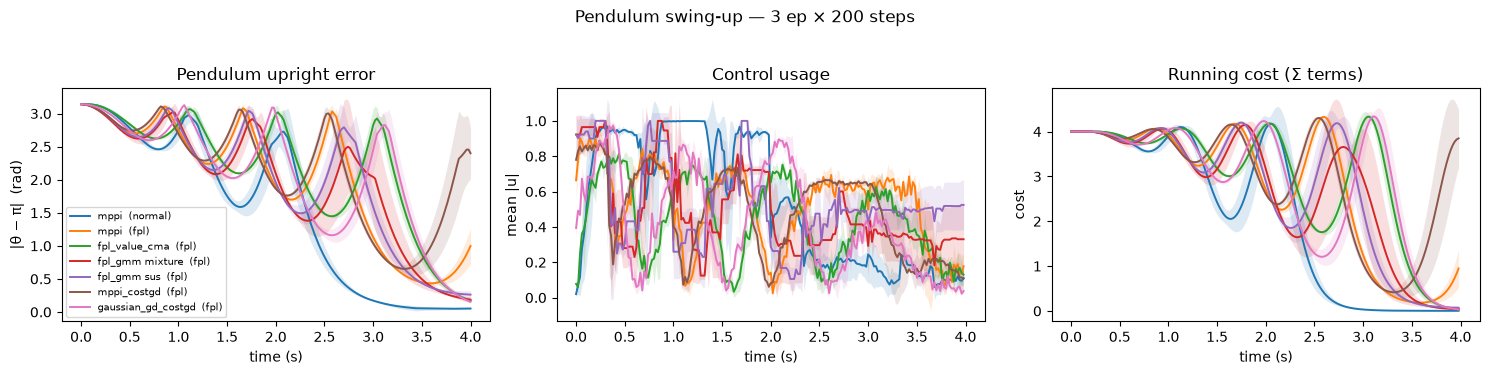

In [26]:
STEPS = 200
N_EPISODES = 3

study = run_study(TASK, CONFIGS, steps=STEPS, n_episodes=N_EPISODES,
                  init_fn=init_hang_down,
                  **SHARED)

plot_study(study, lambda r: pendulum_metrics(r, task), pendulum_panels(), dt=DT,
           title=f"Pendulum swing-up — {N_EPISODES} ep × {STEPS} steps")
summarize(study, lambda r: pendulum_metrics(r, task), ["err", "cost", "u_mag"])

## (optional) Render a video of one config

Set `RUN_VIDEO = True` to render an mp4 of a single config and embed it.

In [29]:
RUN_VIDEO = True
if RUN_VIDEO:
    from IPython.display import Video, display
    from analytic_mppi.eval import init_hang_down
    res = render_video(TASK, FplGmmSampler, steps=500, out_path="/tmp/pendulum_fpl_gmm.mp4",
                   cost_mode="fpl_discounted", init_fn=init_hang_down,
                   allocation="mixture", sigma_max=1.5, sigma_min=0.1, **SHARED)

    print(f"plan {res['plan_ms']:.1f} ms/step")
    display(Video(str(res["path"]), embed=True, width=360))
else:
    print("set RUN_VIDEO = True to render")

plan 0.7 ms/step
